<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 2: 기본 모델링**

## **미션 설명**

- 이번 단계에서는 다음과 같이 2개의 미션을 수행합니다.

### 미션 6: 전처리

- 다음과 같은 이유로 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
    - 0점은 '매우 불만족'보다 낮은 점수가 아니라 '해당 없음'을 의미하는 경우가 많습니다.
    - 만약 0, 1, 2, 3, 4, 5 그대로 넣으면, 모델은 0을 1보다 더 나쁜 것으로 학습하여 예측에 오류가 생길 수 있습니다.
    - 만족도 1점과 2점의 차이가 4점과 5점의 차이와 물리적으로 동일하지 않습니다.
    - 가변수화를 하면 모델이 각 점수를 독립적으로 학습할 수 있어 더 유연한 모델이 될 것입니다.
- 모델링을 위해 x, y로 분리하고 학습용/검증용 데이터로 분리합니다.
- 스케일링을 수행합니다.

### 미션 7: 모델링

- 4개 이상의 딥러닝 모델을 만들어 성능을 확인합니다.
- 모델 이름은 model1, model2, model3, model4...로 구분합니다.
- 마지막 모델의 경우 예측 성능을 높이기 위해 다양한 시도를 해봅니다.
- 가장 성능이 좋은 모델을 저장합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [81]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [82]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [83]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 데이터 불러오기

- 이전 과정에서 저장한 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'data.csv' --> data
    

In [84]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

In [85]:
# 크기(행, 열) 확인
print(data.shape)

(19278, 23)


## **2. 미션 6: 전처리**

- 결측치 처리는 이전 과정에서 완료가 된 상태입니다.
- 딥러닝 모델링을 위해 필요한 전처리를 수행합니다.

### (1) 가변수화

- 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
- 대상 변수는 'Inflight wifi service'부터 'Cleanliness'까지 14개 입니다.
- 일관된 가변수화 결과를 위해 Category 형 변수로 변환합니다.

In [86]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# Category 형 변수로 변환
for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

# 가변수화
data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

# 확인
data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction,Inflight wifi service_1,...,Inflight service_1,Inflight service_2,Inflight service_3,Inflight service_4,Inflight service_5,Cleanliness_1,Cleanliness_2,Cleanliness_3,Cleanliness_4,Cleanliness_5
0,1,1,35.0,0,1,349,0,0.0,1,0,...,1,0,0,0,0,0,0,0,0,1
1,0,1,40.0,0,0,920,10,3.0,1,1,...,0,0,0,1,0,0,0,0,0,1
2,0,1,52.0,0,0,3979,21,7.0,1,1,...,0,0,0,1,0,0,0,0,1,0
3,1,1,47.0,0,1,141,142,158.0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,1,1,33.0,0,0,3153,0,0.0,1,0,...,0,1,0,0,0,0,0,1,0,0


### (2) 데이터 분할

- x, y를 분리한 후 학습용/검증용 데이터를 8:2로 분리합니다.

In [87]:
target = 'Satisfaction'
x = data.drop(target, axis=1)
y = data.loc[:,target]

In [88]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1)

### (3) 스케일링

- MinMaxScaler()를 사용해 스케일링을 수행합니다.

In [89]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3. 미션 7: 모델링**

- 다음과 같이 4개 이상의 모델을 만들고 성능을 확인합니다.
    - 모델 1: Base line 모델(Hidden Layer 없이 모델 생성)
    - 모델 2: 복잡한 모델 생성(최소 5개 이상의 Hidden Layer 추가)
    - 모델 3 ~ n: 모델 튜닝(학습률, epoch 조정, Dropout, Early Stopping 등 모델 성능을 높이기 위한 다양한 시도)


### (1) 모델 1

- 우선 모델을 선언합니다.

In [90]:
clear_session()

nfeatuals = x.shape[1]

model = Sequential([
    Input(shape = (nfeatuals, )),
    Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            79 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [91]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy')

In [92]:
hist = model.fit(x_train,y_train,epochs=20, validation_split=0.2, verbose=0).history

- 학습 곡선을 확인합니다.

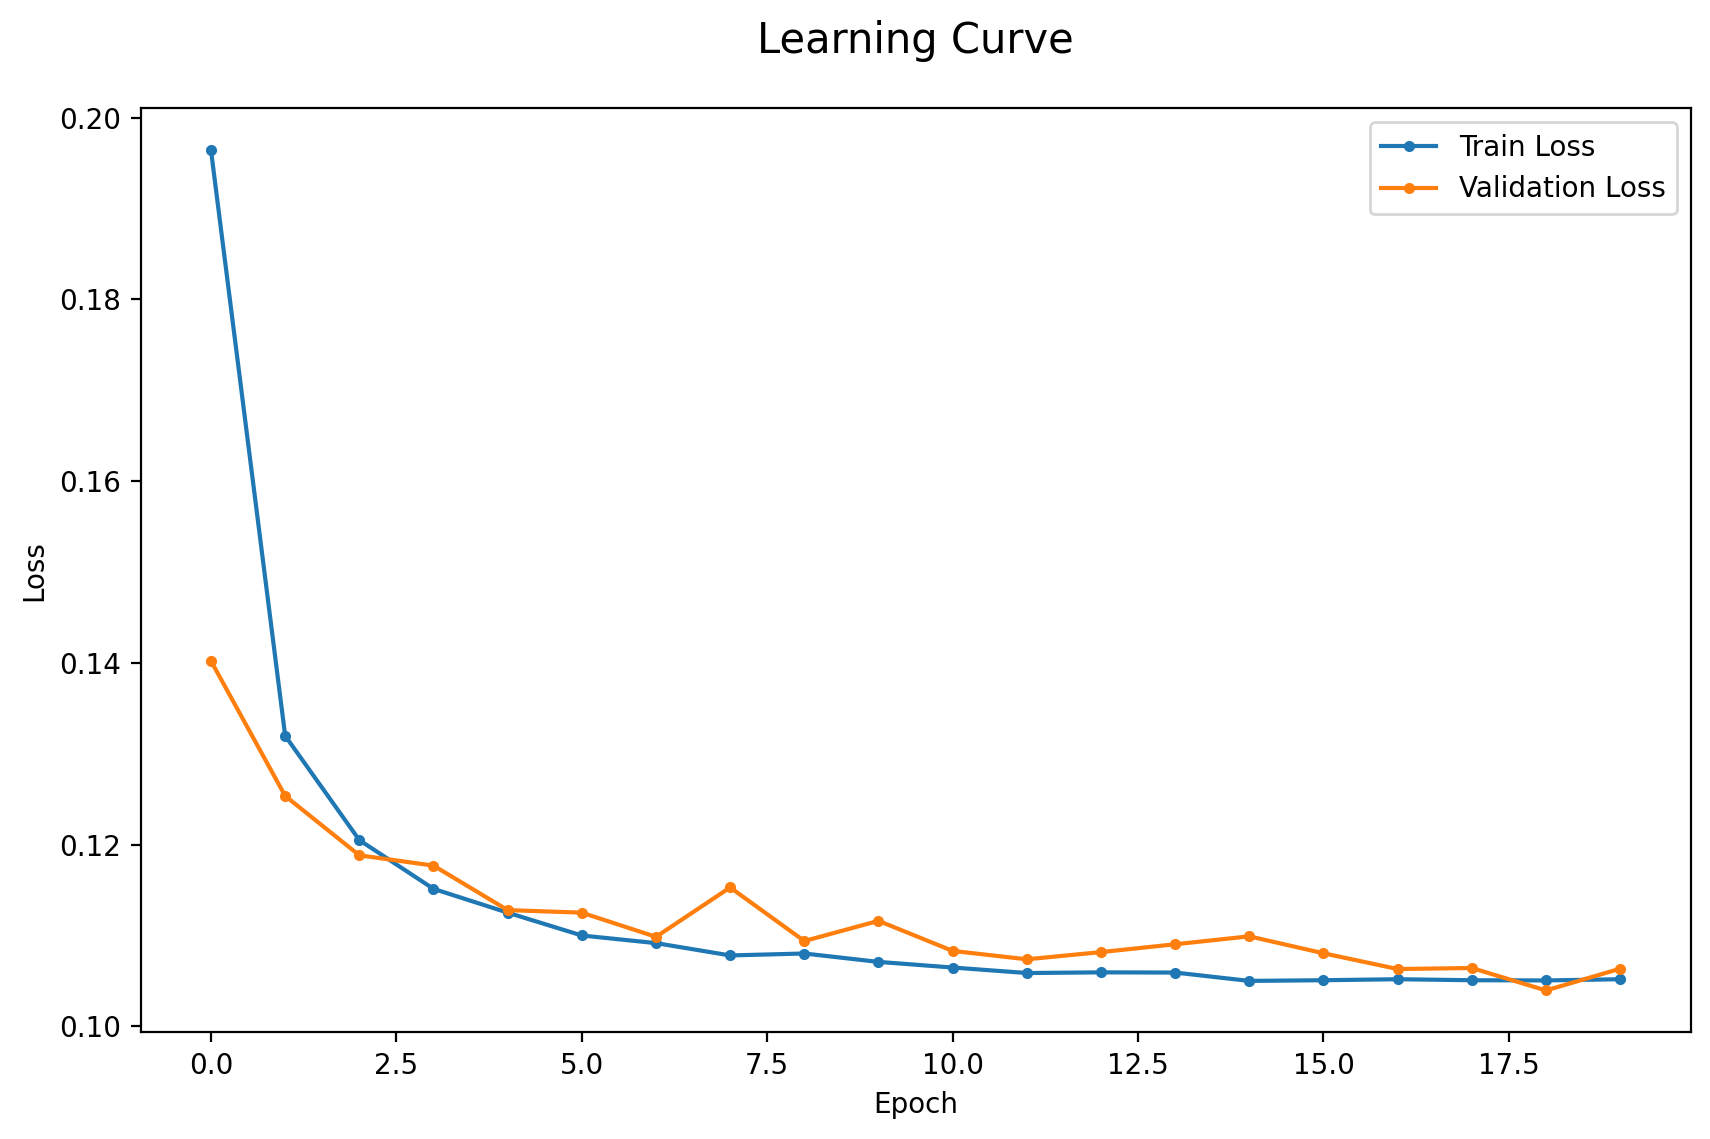

In [93]:
dl_history_plot(hist)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [94]:
y_pred = model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [95]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))

[[ 266   92]
 [  70 3428]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       358
           1       0.97      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.88      0.86      0.87      3856
weighted avg       0.96      0.96      0.96      3856



### (2) 모델 2

- 모델을 선언합니다.

In [96]:
clear_session()

nfeatuals = x.shape[1]

model = Sequential([
    Input(shape = (nfeatuals, )),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(4,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,841 (30.63 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [97]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy')


In [98]:
hist = model.fit(x_train,y_train,epochs=20, validation_split=0.2, batch_size=32, verbose=0 ).history

- 학습 곡선을 확인합니다.

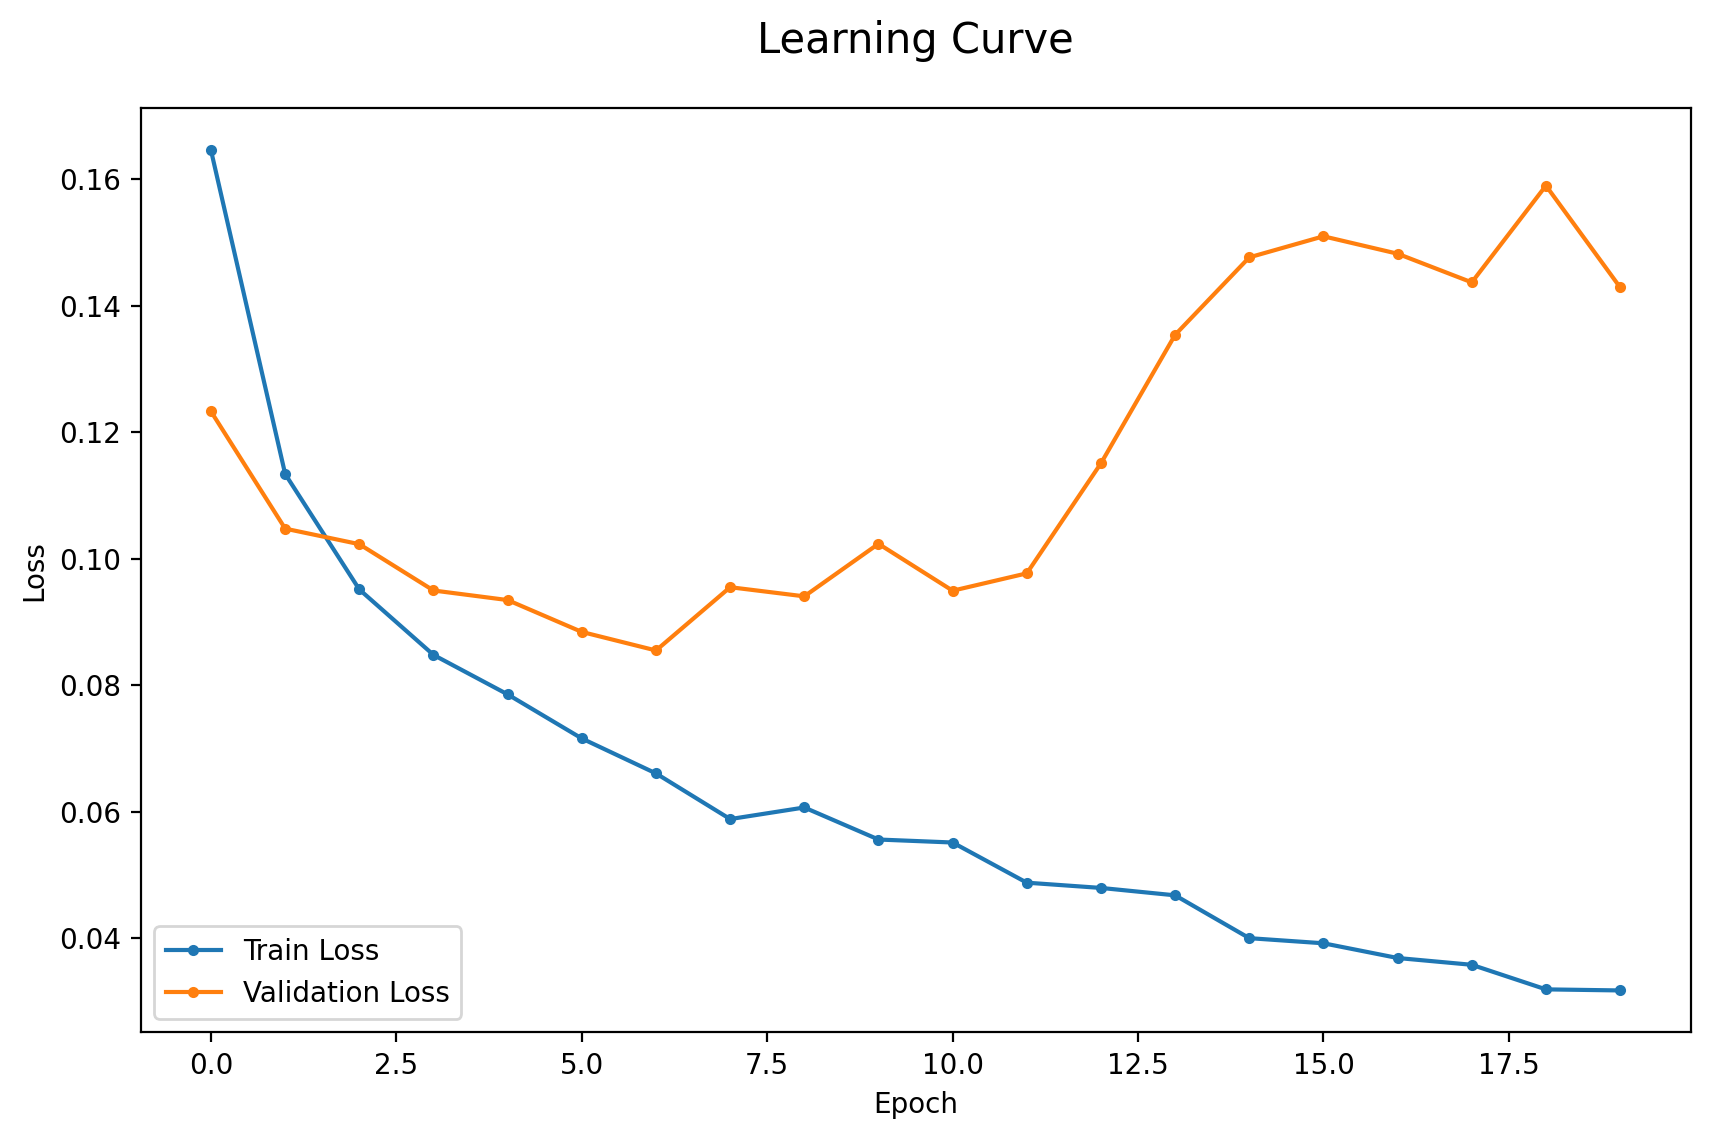

In [99]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [100]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))

[[ 266   92]
 [  70 3428]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       358
           1       0.97      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.88      0.86      0.87      3856
weighted avg       0.96      0.96      0.96      3856



### (3) 모델 3: Dropout

- 모델을 선언합니다.

In [101]:
clear_session()

nfeatuals = x.shape[1]

model = Sequential([
    Input(shape = (nfeatuals, )),
    Dense(16,activation='relu'),
    Dropout(0.3),
    Dense(8,activation='relu'),
    Dropout(0.3),
    Dense(4,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [102]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy')

In [103]:
hist = model.fit(x_train,y_train,epochs=20, validation_split=0.2, batch_size=32, verbose=0 ).history

- 학습 곡선을 확인합니다.

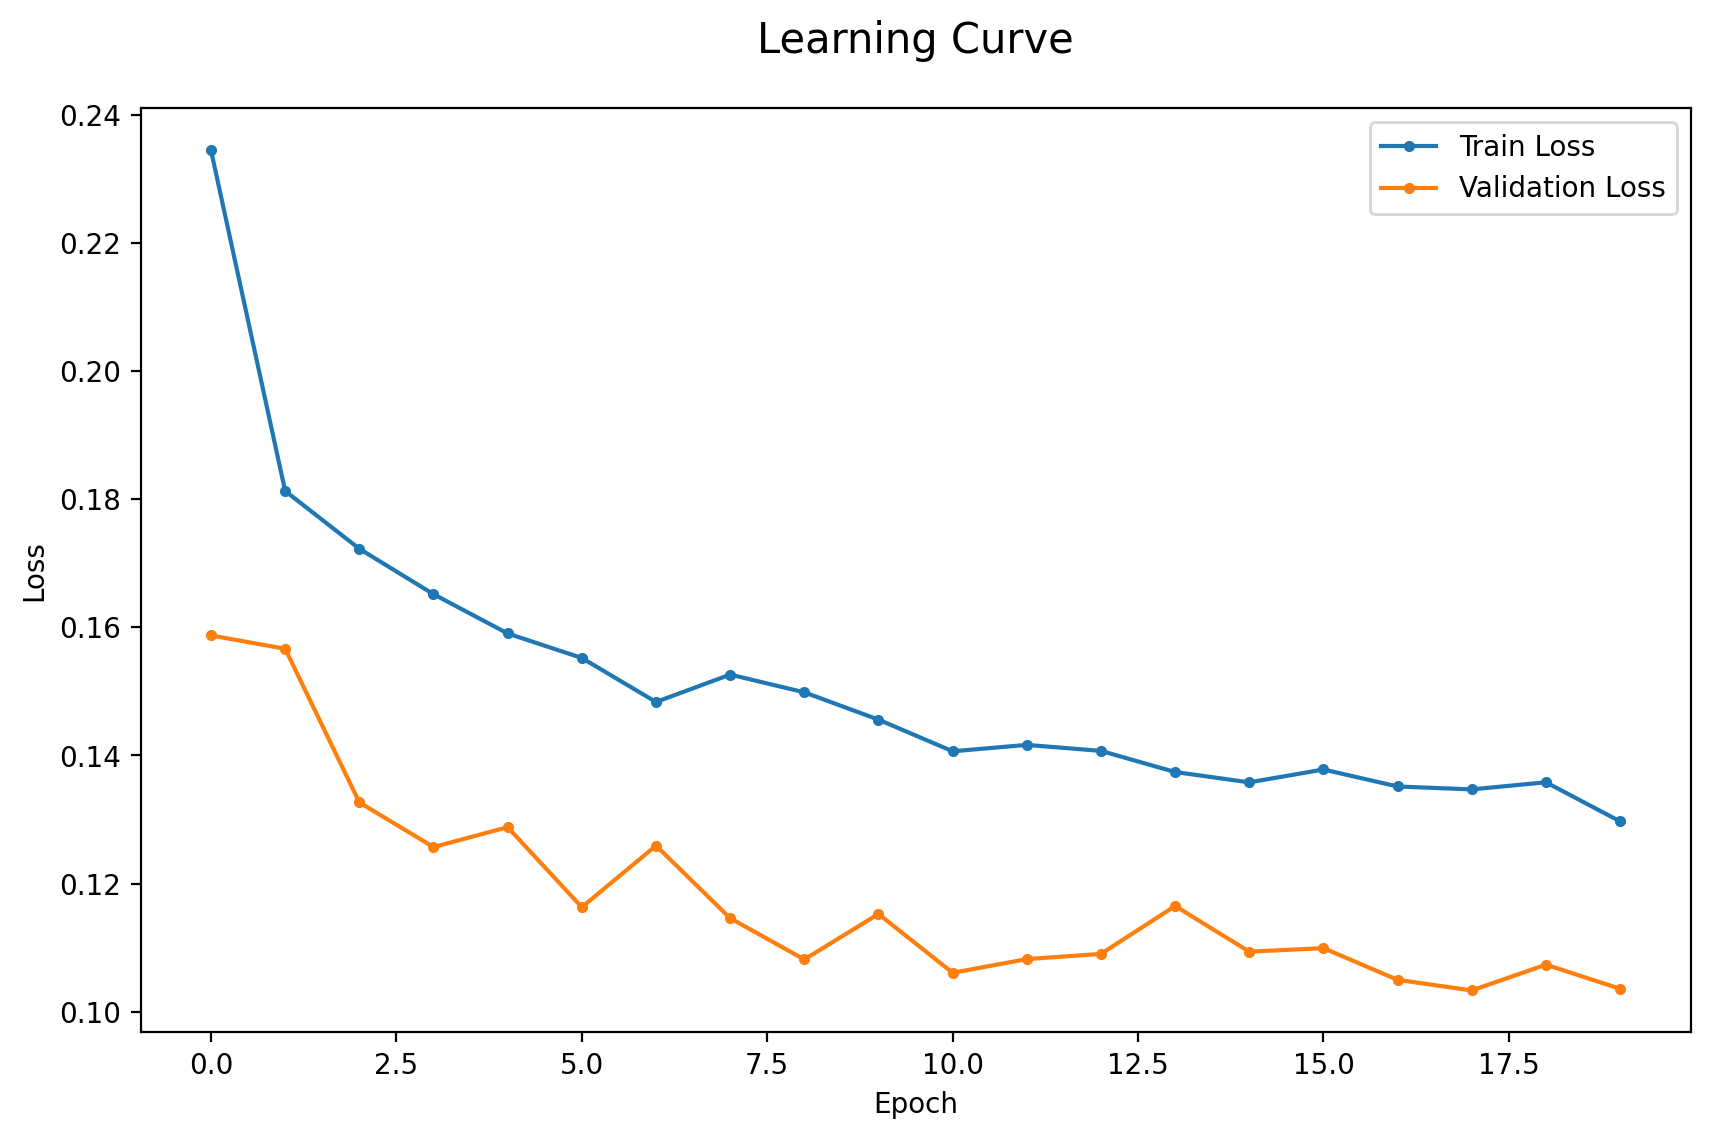

In [104]:
dl_history_plot(hist)


- 검증 데이터로 예측을 수행하고 성능을 확인합니다.

In [105]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))


[[ 266   92]
 [  70 3428]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       358
           1       0.97      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.88      0.86      0.87      3856
weighted avg       0.96      0.96      0.96      3856



### (4) 모델 4: Early Stopping

- 모델을 선언합니다.

In [106]:
clear_session()

nfeatuals = x.shape[1]

model = Sequential([
    Input(shape = (nfeatuals, )),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(8,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,409 (28.94 KB)

 Trainable params: 7,409 (28.94 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [107]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

In [108]:
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, verbose=1)

In [109]:
hist = model.fit(x_train,y_train,epochs=40, validation_split=0.2, callbacks=[es], batch_size=32, verbose=0 ).history

Epoch 18: early stopping


- 학습 곡선을 확인합니다.

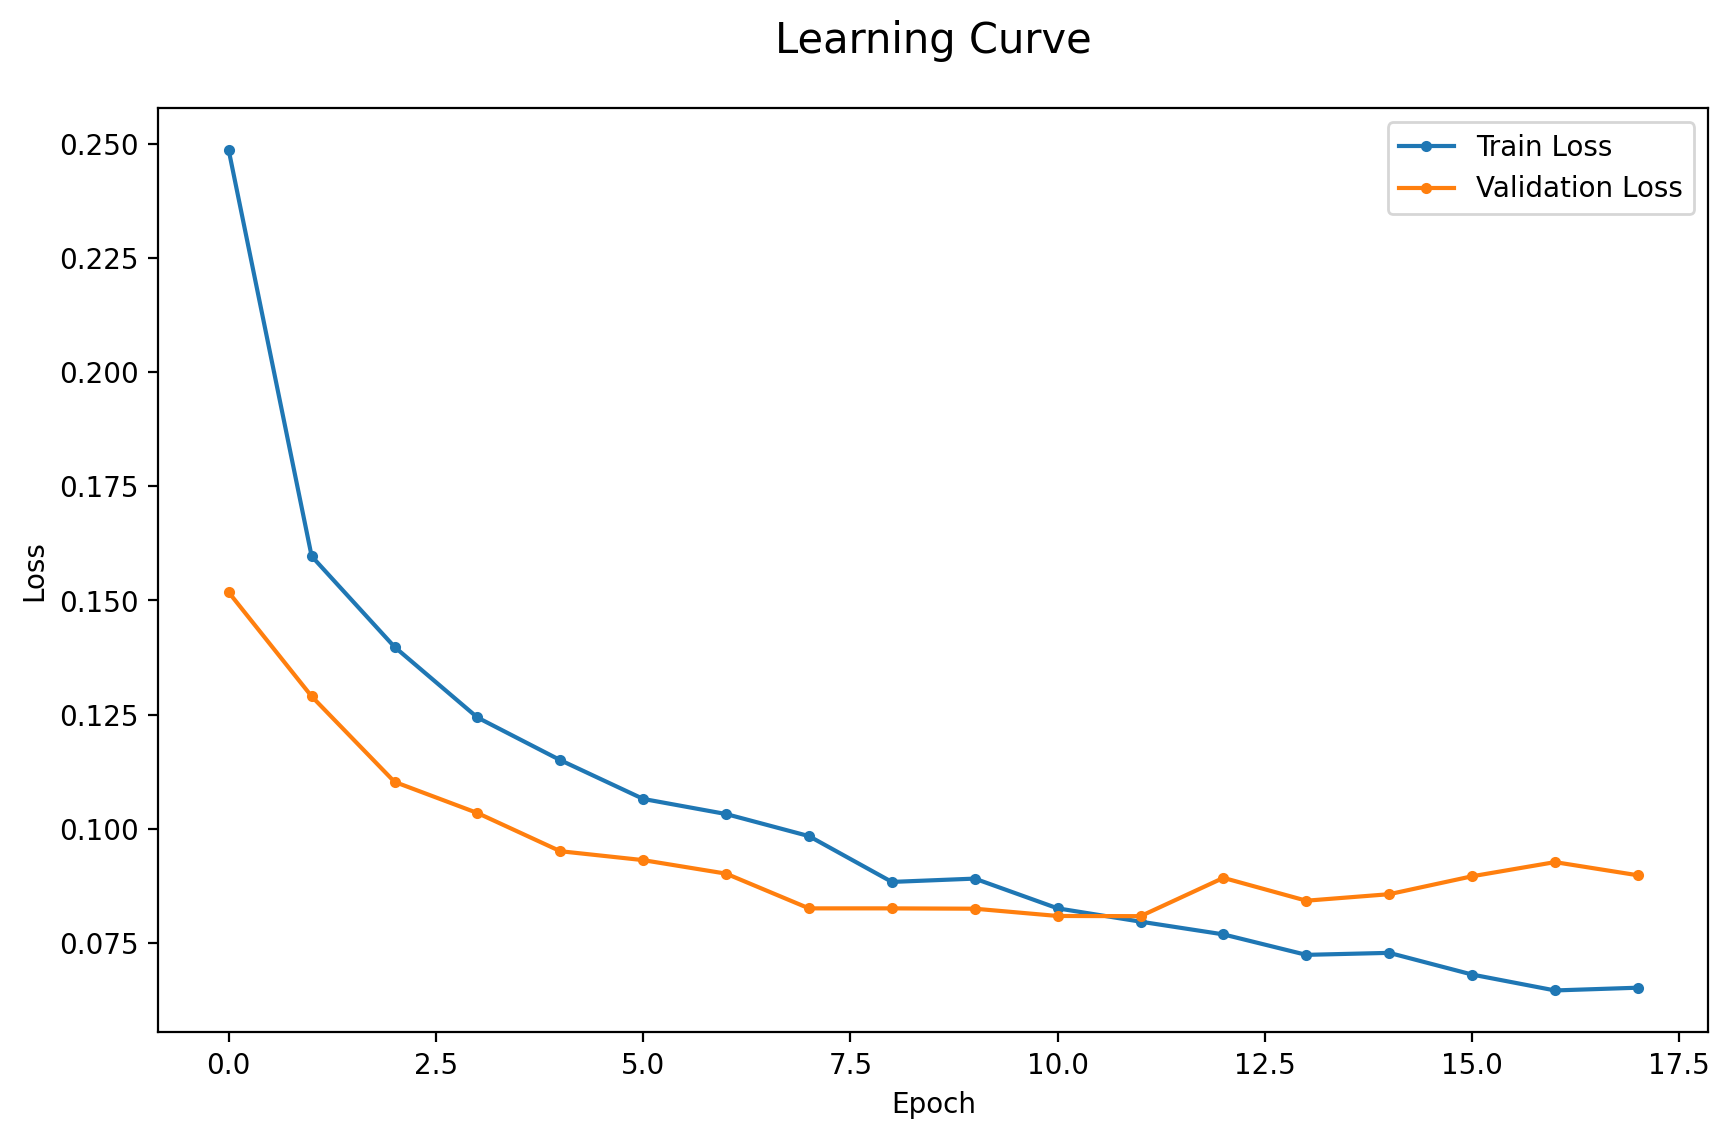

In [110]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [111]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))


[[ 266   92]
 [  70 3428]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       358
           1       0.97      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.88      0.86      0.87      3856
weighted avg       0.96      0.96      0.96      3856



### (5) 저장

- 학습용 데이터 스케일링에 사용한 스케일러를 **scaler.pkl** 파일로 저장합니다.
- **joblib.dump()** 함수를 사용합니다.

In [112]:
# 스케일러 저장
joblib.dump(scaler, path + 'scaler.pkl')

['/content/drive/MyDrive/project01/scaler.pkl']

- 성능이 가장 높은 모델을 **base_model.keras** 파일로 저장합니다.
- **save()** 메서드를 사용합니다.

In [113]:
# 모델 저장
model.save(path + 'base_model.keras')